# Learners Academic Performance Prediction System

### Project Overview

This project develops a semester-level academic performance prediction system that classifies students into predefined academic risk categories. Instead of predicting individual course outcomes, the system evaluates overall semester performance using aggregated academic history, engagement behavior, workload context, and trend-based indicators.

The prediction target is defined as:

- **0 → At-Risk (GPA < 2.0)**
- **1 → Medium (2.0 – 3.5)**
- **2 → High (GPA > 3.5)**

The primary objective is to build an interpretable early-warning framework that enables timely academic intervention. By operating at the semester level, the system aligns with how institutions typically monitor academic standing and implement support mechanisms.




### Dataset Description

The dataset contains **7,000 semester-level records**, where:

- Each row represents **one student in one semester**
- A student may appear across multiple semesters
- The dataset contains **16 total features**, including the target variable

The dataset was **synthetically generated** for the following reasons:

1. **Privacy Protection** – Academic performance data is highly sensitive. Synthetic generation avoids exposing real student records.
2. **Controlled Feature Engineering** – Relationships between GPA, engagement, workload, and performance were intentionally modeled to reflect realistic academic dynamics.
3. **Scalability & Reproducibility** – Synthetic data allows controlled experimentation without institutional data access limitations.
4. **Balanced Class Representation** – Ensures sufficient samples across risk categories for model training and evaluation.

Although synthetic, the dataset is structured to simulate realistic academic patterns such as:
- Higher GPA correlating with higher performance classification
- Declining GPA trends increasing at-risk probability
- Lower engagement correlating with poorer academic outcomes
- High grade variability indicating instability




### Feature Dictionary and Rationale

| Feature Name | Description | Category | Rationale for Inclusion |
|--------------|------------|----------|--------------------------|
| **student_id** | Unique identifier for each student | Identifier | Enables longitudinal tracking; not used as predictive input. |
| **semester_id** | Semester reference (e.g., 2026S1) | Temporal Identifier | Allows ordering of semesters and trend computation. |
| **cumulative_gpa_before_sem** | Overall GPA before current semester | Academic History | Represents baseline academic ability; strong predictive signal. |
| **previous_semester_gpa** | GPA from the immediate previous semester | Academic History | Captures recent academic condition. |
| **avg_gpa_change_from_previous_semester** | `previous_semester_gpa − cumulative_gpa_before_sem` | Trend Indicator | Measures improvement or decline relative to long-term average. |
| **total_credits** | Total credit load in semester | Workload | Higher load may increase academic pressure and risk. |
| **num_courses** | Number of courses taken | Workload | Provides context for aggregated engagement metrics. |
| **avg_module_completion_pct** | Average module completion rate | Engagement | Reflects consistency in content engagement. |
| **avg_video_watch_pct** | Average video watch percentage | Engagement | Indicates depth of content interaction. |
| **avg_quiz_score** | Average quiz score across courses | Assessment | Early performance signal before final grading. |
| **total_late_submissions** | Total late assignment submissions | Behavioral | Indicates time management and academic discipline. |
| **days_active** | Number of active learning days | Engagement Frequency | Measures regularity of study behavior. |
| **days_since_last_activity** | Days since last system activity | Engagement Recency | Detects disengagement risk. |
| **num_failed_courses** | Number of failed courses | Performance Signal | Direct academic risk indicator. |
| **grade_stddev_across_courses** | Standard deviation of grades | Stability Metric | Captures performance consistency across subjects. |
| **semester_performance_class** | Target classification (0,1,2) | Target Variable | Defines semester-level performance category. |

---

### Conceptual Design Rationale

The feature set is structured around five predictive dimensions:

#### 1. Academic Ability (Baseline Strength)
Cumulative GPA and previous semester GPA represent long-term and short-term academic competence.

#### 2. Performance Trend (Momentum)
The GPA change feature captures directionality. Improvement suggests recovery, while decline may signal emerging risk.

#### 3. Workload Context (Academic Pressure)
Total credits and number of courses contextualize performance and engagement intensity.

#### 4. Behavioral Engagement (Effort Indicators)
Completion rates, activity frequency, and quiz performance represent learning effort and participation.

#### 5. Stability and Risk Signals
Failed courses and grade variability identify instability that may not be visible in GPA alone.

---

### Why this Approach is Optimal

Academic systems naturally aggregate performance hierarchically:

- Course grades → Semester GPA  
- Semester GPA → Cumulative GPA  

Modeling at the semester level provides a balanced abstraction:
- More informative than isolated course predictions  
- More actionable than cumulative GPA alone  
- Captures trend, workload, engagement, and stability simultaneously  

This structure enables a comprehensive and interpretable academic monitoring system suitable for institutional early intervention frameworks.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from plotly.subplots import make_subplots
import plotly.express as px

In [2]:
os.listdir(".")

['Student Performance.ipynb']

In [3]:
df = pd.read_csv(r'D:\Student Performance\data\raw\student_performance_large.csv')

In [4]:
df

,student_id,semester_id,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,total_credits,num_courses,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,STU10000,2026S1,4.591961,4.479338,-0.112623,23,8,100.000000,81.759833,37.362445,4,18,0,1,0.596012,2
1,STU10001,2026S1,4.039204,3.962125,-0.077079,23,8,81.969378,54.215486,68.956015,5,77,20,0,0.459519,1
2,STU10002,2026S1,4.043330,4.152361,0.109031,23,8,93.143135,100.000000,48.833631,2,103,6,0,0.877838,2
3,STU10003,2026S1,1.509105,2.171844,0.662739,23,8,97.383823,100.000000,83.808956,5,87,43,4,0.523985,0
4,STU10004,2026S1,2.527878,2.614541,0.086663,23,8,61.077442,83.311495,53.962490,3,39,39,0,0.974451,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,STU16995,2026S1,2.570066,2.213152,-0.356914,23,8,55.332391,51.017577,86.491137,2,110,35,2,0.630619,1
6996,STU16996,2026S1,3.572218,3.826320,0.254102,23,8,86.165616,66.066103,46.577289,7,33,33,0,0.406263,1
6997,STU16997,2026S1,4.298665,4.434539,0.135874,23,8,33.752627,47.096219,72.595914,3,43,20,0,0.809526,2
6998,STU16998,2026S1,3.227033,2.876140,-0.350893,23,8,83.240169,95.156303,72.713591,5,116,32,1,0.631049,1


In [5]:
# high-level view of data count and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   student_id                             7000 non-null   object 
 1   semester_id                            7000 non-null   object 
 2   cumulative_gpa_before_sem              7000 non-null   float64
 3   previous_semester_gpa                  7000 non-null   float64
 4   avg_gpa_change_from_previous_semester  7000 non-null   float64
 5   total_credits                          7000 non-null   int64  
 6   num_courses                            7000 non-null   int64  
 7   avg_module_completion_pct              7000 non-null   float64
 8   avg_video_watch_pct                    7000 non-null   float64
 9   avg_quiz_score                         7000 non-null   float64
 10  total_late_submissions                 7000 non-null   int64  
 11  days

In [6]:
#getting descriptive statistics from the data
df.describe()

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,total_credits,num_courses,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
count,7000.000000,7000.000000,7000.000000,7000.0,7000.0,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,3.560013,3.556102,-0.003911,23.0,8.0,74.869603,69.369586,64.895409,3.023571,64.742000,29.069571,0.837429,0.603853,1.233429
std,0.745524,0.797827,0.294617,0.0,0.0,14.352897,18.674447,17.408492,1.746186,31.828063,17.174974,0.914317,0.288076,0.509739
min,1.505011,0.846696,-1.009589,23.0,8.0,20.000000,10.000000,20.000000,0.000000,10.000000,0.000000,0.000000,0.100000,0.000000
25%,2.972877,2.967059,-0.203901,23.0,8.0,64.929154,56.714992,53.027084,2.000000,37.000000,14.000000,0.000000,0.390721,1.000000
50%,3.573016,3.576921,-0.001710,23.0,8.0,75.234049,69.708588,65.034815,3.000000,65.000000,29.000000,1.000000,0.604498,1.000000
75%,4.189782,4.193598,0.201080,23.0,8.0,85.484815,83.140284,76.881189,4.000000,92.000000,44.000000,1.000000,0.801093,2.000000
max,4.799351,5.000000,1.025584,23.0,8.0,100.000000,100.000000,100.000000,12.000000,119.000000,59.000000,5.000000,1.500000,2.000000


Since the data is synthetic, it is generally clean and does not require any cleaning or transformation process

## Exploratory Data Analysis

In [7]:
df.columns

Index(['student_id', 'semester_id', 'cumulative_gpa_before_sem',
       'previous_semester_gpa', 'avg_gpa_change_from_previous_semester',
       'total_credits', 'num_courses', 'avg_module_completion_pct',
       'avg_video_watch_pct', 'avg_quiz_score', 'total_late_submissions',
       'days_active', 'days_since_last_activity', 'num_failed_courses',
       'grade_stddev_across_courses', 'semester_performance_class'],
      dtype='object')

In [8]:
predictors = df.drop(['semester_performance_class','student_id', 'semester_id'], axis = 1)
len(predictors.columns)

13

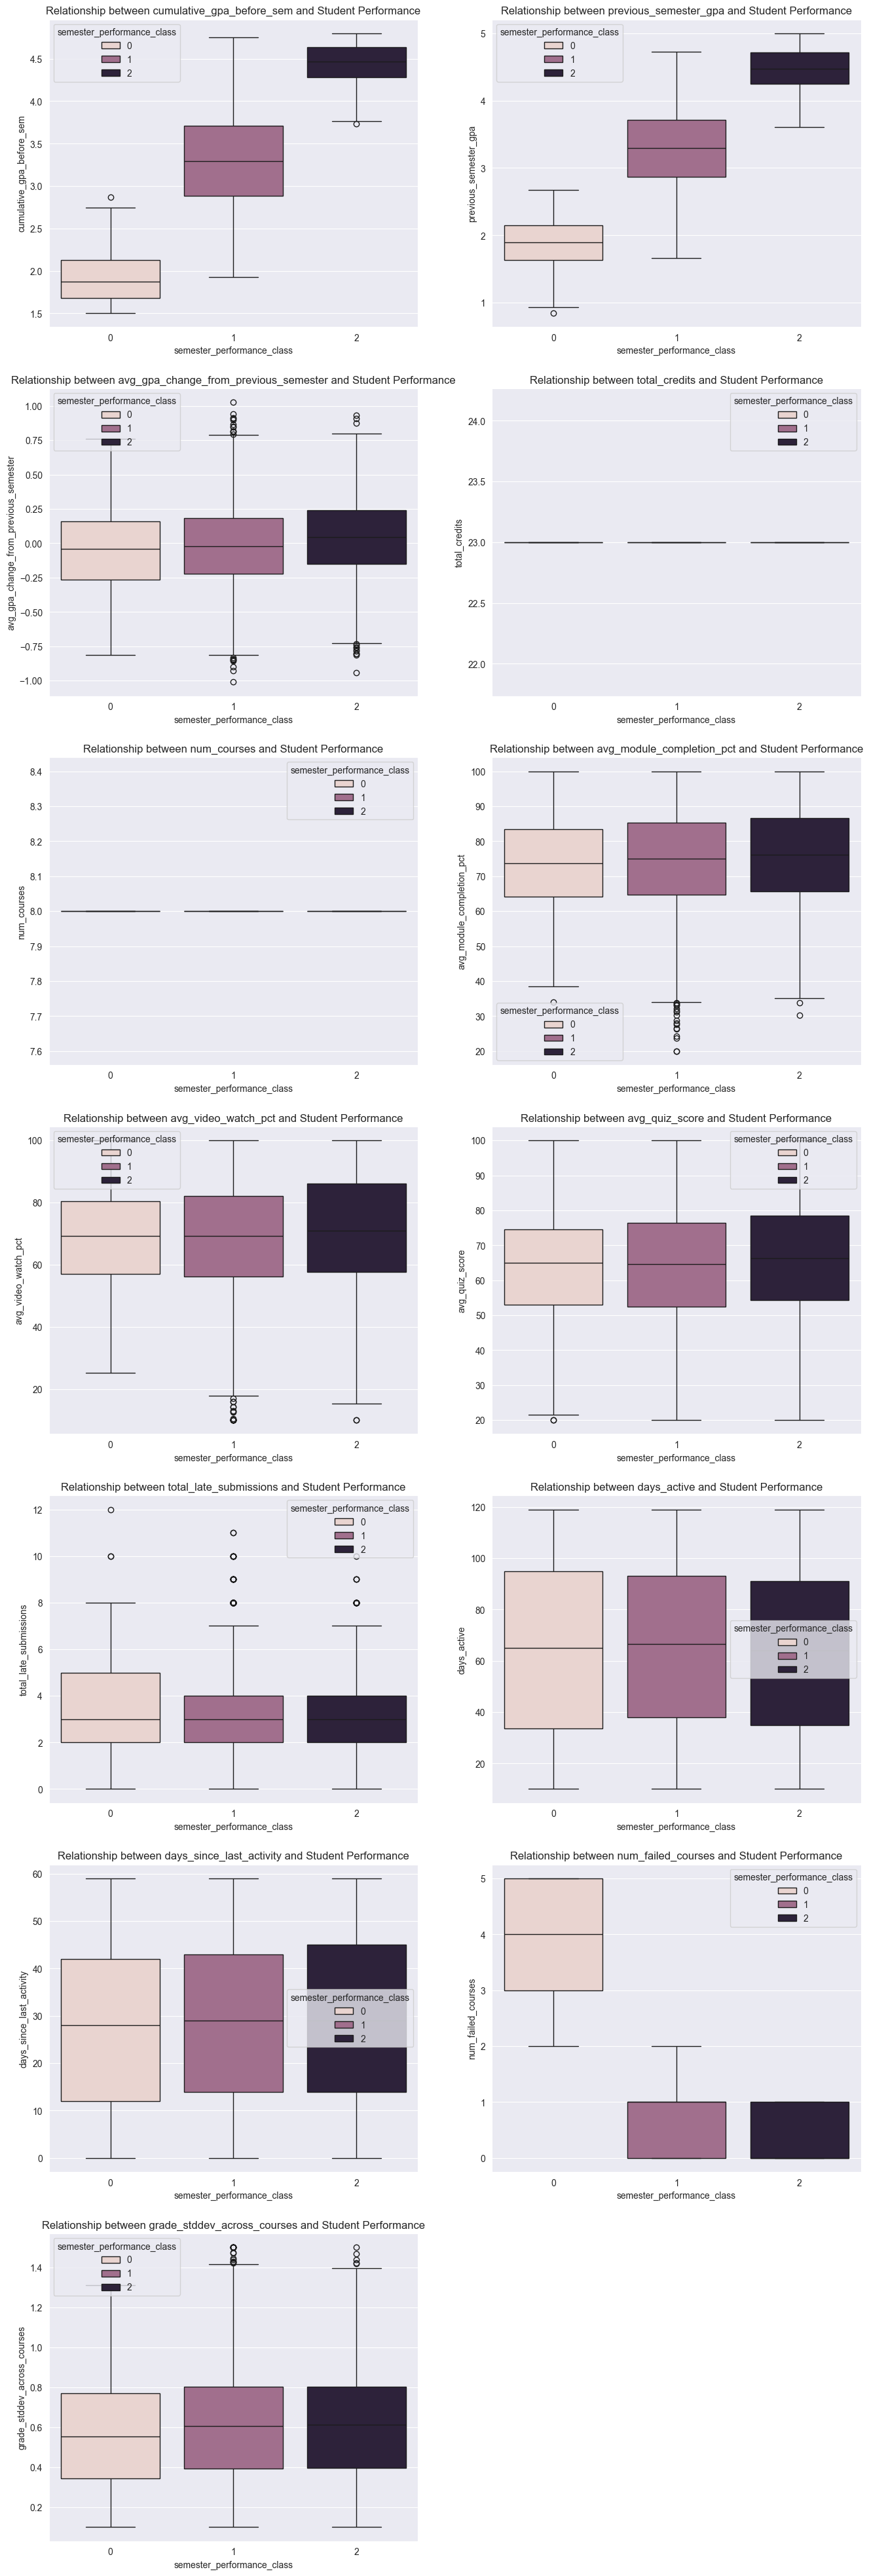

In [9]:
sns.set_style('darkgrid')
fig = plt.figure(figsize = (16,50))
b = 1
for col in predictors:
    axis = fig.add_subplot(7,2,b)
    sns.boxplot(y = col, x = 'semester_performance_class', data = df, hue = 'semester_performance_class')
    plt.title(f'Relationship between {col} and Student Performance')
    b+=1

### 📊 Exploratory Data Analysis (EDA) – Key Insights

#### Strongest Predictors
- **Cumulative GPA (cumulative_gpa_before_sem)** and **Previous Semester GPA (previous_semester_gpa)** show clear, monotonic separation across performance classes.
- **Number of Failed Courses (num_failed_courses)** strongly differentiates At-Risk students from Medium and High performers.
- These features are expected to dominate model predictions.


#### Moderate Predictors
- **Average Quiz Score (avg_quiz_score)** increases consistently with performance class.
- **Module Completion % (avg_module_completion_pct)** and **Video Watch % (avg_video_watch_pct)** show positive association with higher performance.
- **Total Late Submissions (total_late_submissions)** shows a mild inverse relationship with performance.
- **Days Active (days_active)** shows weak-to-moderate positive association with higher performance.
- **GPA Trend (avg_gpa_change_from_previous_semester)** adds directional insight but with considerable overlap between classes.


#### Weak / Low-Impact Features
- **Total Credits (total_credits)** and **Number of Courses (num_courses)** show minimal variation across classes.
- **Grade Standard Deviation (grade_stddev_across_courses)** does not significantly separate performance groups.
- **Days Since Last Activity (days_since_last_activity)** shows high overlap between classes.

#### Overall Pattern
- Historical academic performance is the strongest driver of classification.
- Engagement metrics contribute secondary but meaningful predictive signals.
- Workload-related features currently add limited predictive value.

#### Modeling Implications
- Expect strong reliance on GPA-based features.
- Engagement variables improve nuance and interpretability.
- Some workload-related features may be candidates for removal or redesign.

### Feature Correlation

***How much effect does each attribute have on the target variable?***

We will use a correlation matrix to gauge how much effect numerical features have on each other 

In [10]:
matrix = df.drop(['student_id', 'semester_id'], axis = 1).corr()
matrix

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,total_credits,num_courses,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
cumulative_gpa_before_sem,1.000000,0.929334,-0.013836,NaN,NaN,0.005496,0.013405,-0.007047,0.010354,-0.021066,0.002501,-0.482865,0.018200,0.811448
previous_semester_gpa,0.929334,1.000000,0.356345,NaN,NaN,0.004780,0.016928,-0.004683,0.011728,-0.019108,0.003531,-0.469733,0.020553,0.789736
avg_gpa_change_from_previous_semester,-0.013836,0.356345,1.000000,NaN,NaN,-0.000962,0.011920,0.005151,0.005558,0.001561,0.003233,-0.050161,0.009602,0.085257
total_credits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_courses,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_module_completion_pct,0.005496,0.004780,-0.000962,NaN,NaN,1.000000,-0.010834,0.004506,-0.003956,-0.004524,0.001355,-0.013101,-0.016980,0.037811
avg_video_watch_pct,0.013405,0.016928,0.011920,NaN,NaN,-0.010834,1.000000,-0.000766,-0.005243,-0.005570,-0.013868,-0.003426,-0.018965,0.050537
avg_quiz_score,-0.007047,-0.004683,0.005151,NaN,NaN,0.004506,-0.000766,1.000000,-0.006681,0.009821,-0.016220,-0.017622,-0.005609,0.038836
total_late_submissions,0.010354,0.011728,0.005558,NaN,NaN,-0.003956,-0.005243,-0.006681,1.000000,-0.001286,0.006829,0.048578,0.010647,-0.094307
days_active,-0.021066,-0.019108,0.001561,NaN,NaN,-0.004524,-0.005570,0.009821,-0.001286,1.000000,0.000069,-0.002158,-0.014950,-0.022733


<Axes: >

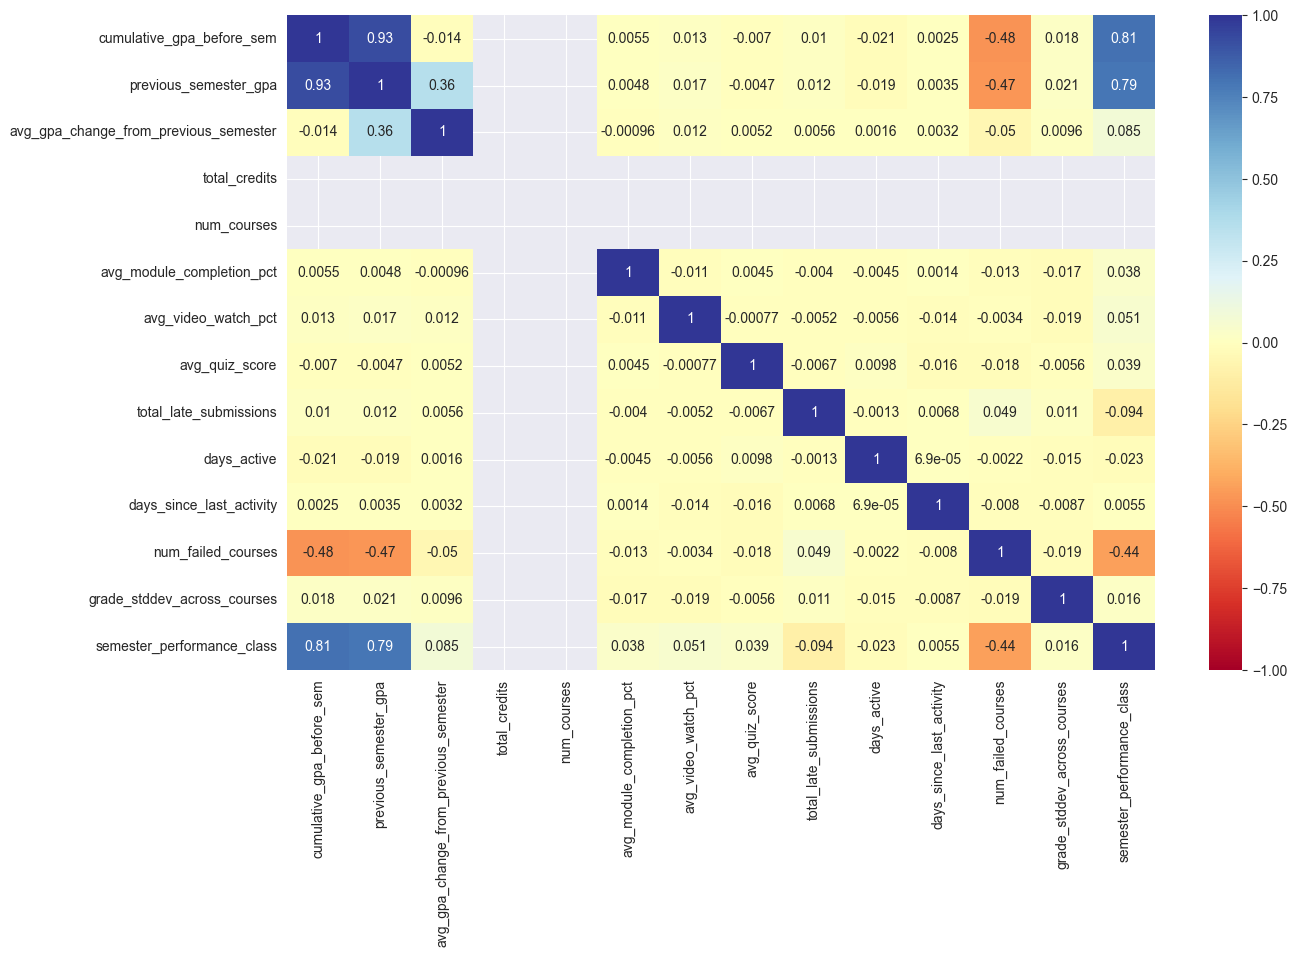

In [11]:
plt.figure(figsize = (14,8.5))
sns.heatmap(matrix, cmap = 'RdYlBu', annot = True, vmin=-1, vmax=1)

The correlation matrix reveals a clear structural pattern in the dataset, with academic history emerging as the dominant predictive signal. The strongest positive correlations with the target variable (semester_performance_class) are observed for cumulative_gpa_before_sem (≈ 0.81) and previous_semester_gpa (≈ 0.79), indicating that historical academic performance strongly determines semester classification. Additionally, these two GPA features are highly correlated with each other (≈ 0.93), which suggests potential multicollinearity and redundancy in modeling. The number of failed courses shows a moderate negative correlation with performance class (≈ -0.44), confirming that higher failure counts are associated with lower performance categories. Engagement-related variables such as average quiz score, module completion percentage, and video watch percentage exhibit weak but positive correlations with the target, indicating that while engagement contributes to performance, it plays a secondary role compared to GPA-based features. The GPA trend variable shows only a weak positive relationship with performance, suggesting it adds nuance rather than acting as a primary predictor.

The NaN values observed for total_credits and num_courses occur because these variables have zero variance — meaning they contain constant values across all observations. Pearson correlation requires variability in both variables; when the standard deviation of a feature is zero, the correlation formula involves division by zero, resulting in undefined (NaN) values. This confirms that these workload-related features do not contribute meaningful information in their current form and may be safely removed from modeling. 

## Model Building and Evaluation

In [12]:
df

,student_id,semester_id,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,total_credits,num_courses,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,STU10000,2026S1,4.591961,4.479338,-0.112623,23,8,100.000000,81.759833,37.362445,4,18,0,1,0.596012,2
1,STU10001,2026S1,4.039204,3.962125,-0.077079,23,8,81.969378,54.215486,68.956015,5,77,20,0,0.459519,1
2,STU10002,2026S1,4.043330,4.152361,0.109031,23,8,93.143135,100.000000,48.833631,2,103,6,0,0.877838,2
3,STU10003,2026S1,1.509105,2.171844,0.662739,23,8,97.383823,100.000000,83.808956,5,87,43,4,0.523985,0
4,STU10004,2026S1,2.527878,2.614541,0.086663,23,8,61.077442,83.311495,53.962490,3,39,39,0,0.974451,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,STU16995,2026S1,2.570066,2.213152,-0.356914,23,8,55.332391,51.017577,86.491137,2,110,35,2,0.630619,1
6996,STU16996,2026S1,3.572218,3.826320,0.254102,23,8,86.165616,66.066103,46.577289,7,33,33,0,0.406263,1
6997,STU16997,2026S1,4.298665,4.434539,0.135874,23,8,33.752627,47.096219,72.595914,3,43,20,0,0.809526,2
6998,STU16998,2026S1,3.227033,2.876140,-0.350893,23,8,83.240169,95.156303,72.713591,5,116,32,1,0.631049,1


In [13]:
#Drop unnecessary columns
df.drop(['student_id', 'semester_id', 'total_credits' , 'num_courses'], axis = 1, inplace = True)

In [14]:
df

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,4.591961,4.479338,-0.112623,100.000000,81.759833,37.362445,4,18,0,1,0.596012,2
1,4.039204,3.962125,-0.077079,81.969378,54.215486,68.956015,5,77,20,0,0.459519,1
2,4.043330,4.152361,0.109031,93.143135,100.000000,48.833631,2,103,6,0,0.877838,2
3,1.509105,2.171844,0.662739,97.383823,100.000000,83.808956,5,87,43,4,0.523985,0
4,2.527878,2.614541,0.086663,61.077442,83.311495,53.962490,3,39,39,0,0.974451,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,2.570066,2.213152,-0.356914,55.332391,51.017577,86.491137,2,110,35,2,0.630619,1
6996,3.572218,3.826320,0.254102,86.165616,66.066103,46.577289,7,33,33,0,0.406263,1
6997,4.298665,4.434539,0.135874,33.752627,47.096219,72.595914,3,43,20,0,0.809526,2
6998,3.227033,2.876140,-0.350893,83.240169,95.156303,72.713591,5,116,32,1,0.631049,1


Before model training, it'll be nice to have a test set that will enable us to test for the model's generalizability ability later on, so let's make a split set of 1500 samples for testing

In [15]:
test = df.sample(1500, random_state = 42).reset_index()

In [16]:
test

,index,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,6500,3.436941,3.624889,0.187949,70.188027,53.724005,98.310122,2,92,0,1,0.564389,1
1,2944,4.313429,4.387844,0.074415,78.040860,100.000000,58.930146,4,24,29,0,0.794373,2
2,2024,3.384605,3.602430,0.217825,70.801342,89.326109,72.556388,2,56,41,1,0.666357,1
3,263,3.788387,3.945002,0.156615,68.326215,68.415855,43.546934,3,52,45,0,0.397882,1
4,4350,2.896336,3.290620,0.394284,83.879674,40.148967,53.964657,3,33,50,2,0.920680,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2354,4.087908,4.336549,0.248641,50.425078,32.161218,47.854894,4,13,26,1,0.643135,1
1496,977,4.798983,4.888631,0.089649,80.464746,65.555532,100.000000,8,58,43,1,0.801965,2
1497,809,3.868990,3.884217,0.015227,83.371542,55.583405,50.848659,5,83,28,0,0.587586,1
1498,3126,3.200762,3.892218,0.691456,55.087706,100.000000,52.336205,2,78,31,0,0.703715,1


In [17]:
#confirmation
rows = []
for val in test['index']:
    rows.append(val)
    train = df.drop(rows, axis = 0)

len(rows)

1500

In [18]:
train

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,4.591961,4.479338,-0.112623,100.000000,81.759833,37.362445,4,18,0,1,0.596012,2
1,4.039204,3.962125,-0.077079,81.969378,54.215486,68.956015,5,77,20,0,0.459519,1
2,4.043330,4.152361,0.109031,93.143135,100.000000,48.833631,2,103,6,0,0.877838,2
3,1.509105,2.171844,0.662739,97.383823,100.000000,83.808956,5,87,43,4,0.523985,0
4,2.527878,2.614541,0.086663,61.077442,83.311495,53.962490,3,39,39,0,0.974451,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,2.570066,2.213152,-0.356914,55.332391,51.017577,86.491137,2,110,35,2,0.630619,1
6996,3.572218,3.826320,0.254102,86.165616,66.066103,46.577289,7,33,33,0,0.406263,1
6997,4.298665,4.434539,0.135874,33.752627,47.096219,72.595914,3,43,20,0,0.809526,2
6998,3.227033,2.876140,-0.350893,83.240169,95.156303,72.713591,5,116,32,1,0.631049,1


In [19]:
test.drop('index',axis = 1, inplace = True)
test

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses,semester_performance_class
0,3.436941,3.624889,0.187949,70.188027,53.724005,98.310122,2,92,0,1,0.564389,1
1,4.313429,4.387844,0.074415,78.040860,100.000000,58.930146,4,24,29,0,0.794373,2
2,3.384605,3.602430,0.217825,70.801342,89.326109,72.556388,2,56,41,1,0.666357,1
3,3.788387,3.945002,0.156615,68.326215,68.415855,43.546934,3,52,45,0,0.397882,1
4,2.896336,3.290620,0.394284,83.879674,40.148967,53.964657,3,33,50,2,0.920680,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,4.087908,4.336549,0.248641,50.425078,32.161218,47.854894,4,13,26,1,0.643135,1
1496,4.798983,4.888631,0.089649,80.464746,65.555532,100.000000,8,58,43,1,0.801965,2
1497,3.868990,3.884217,0.015227,83.371542,55.583405,50.848659,5,83,28,0,0.587586,1
1498,3.200762,3.892218,0.691456,55.087706,100.000000,52.336205,2,78,31,0,0.703715,1


In [20]:
test_x = test.drop('semester_performance_class',axis = 1)
test_y = test['semester_performance_class']

In [21]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import jaccard_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import optuna
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from catboost import CatBoostClassifier

In [22]:
train['semester_performance_class'].value_counts()

semester_performance_class
1    3790
2    1499
0     211
Name: count, dtype: int64

There seems to be an imbalance in this data set, so we will make use of the popular sampling technique, **SMOTE** :(Synthetic Minority Oversampling Technique)

In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
# splitting the target and predictor variables
X = train.drop('semester_performance_class', axis = 1)
Y = train['semester_performance_class']

In [25]:
X

,cumulative_gpa_before_sem,previous_semester_gpa,avg_gpa_change_from_previous_semester,avg_module_completion_pct,avg_video_watch_pct,avg_quiz_score,total_late_submissions,days_active,days_since_last_activity,num_failed_courses,grade_stddev_across_courses
0,4.591961,4.479338,-0.112623,100.000000,81.759833,37.362445,4,18,0,1,0.596012
1,4.039204,3.962125,-0.077079,81.969378,54.215486,68.956015,5,77,20,0,0.459519
2,4.043330,4.152361,0.109031,93.143135,100.000000,48.833631,2,103,6,0,0.877838
3,1.509105,2.171844,0.662739,97.383823,100.000000,83.808956,5,87,43,4,0.523985
4,2.527878,2.614541,0.086663,61.077442,83.311495,53.962490,3,39,39,0,0.974451
...,...,...,...,...,...,...,...,...,...,...,...
6995,2.570066,2.213152,-0.356914,55.332391,51.017577,86.491137,2,110,35,2,0.630619
6996,3.572218,3.826320,0.254102,86.165616,66.066103,46.577289,7,33,33,0,0.406263
6997,4.298665,4.434539,0.135874,33.752627,47.096219,72.595914,3,43,20,0,0.809526
6998,3.227033,2.876140,-0.350893,83.240169,95.156303,72.713591,5,116,32,1,0.631049


In [26]:
Y

0       2
1       1
2       2
3       0
4       1
       ..
6995    1
6996    1
6997    2
6998    1
6999    1
Name: semester_performance_class, Length: 5500, dtype: int64

In [27]:
# We further split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=10)

In [28]:
x_train.shape, x_test.shape, y_test.shape, y_train.shape

((4400, 11), (1100, 11), (1100,), (4400,))

### Model Building

#### Logistic Regression

In [29]:
# Optuna Objective with SMOTE
def objective_smote(trial):
    try:
        C = trial.suggest_float('model__C', 0.01, 100, log=True)
        penalty = trial.suggest_categorical('model__penalty', ['l1', 'l2'])
        class_weight = trial.suggest_categorical('model__class_weight', [None, 'balanced'])
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        pipe = Pipeline([
            ('smote', SMOTE(random_state = 42, k_neighbors = k_neighbors, sampling_strategy='not majority')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                C=C,
                penalty=penalty,
                class_weight=class_weight,
                solver='liblinear',
                max_iter=1000
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc_ovr', n_jobs=-1, error_score='raise')
        
        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization
study_smote = optuna.create_study(direction='maximize')
study_smote.optimize(objective_smote, n_trials=15)

print("\n=== SMOTE Optimization Results ===")
print("Best AUC Score:", study_smote.best_value)
print("Best Parameters:", study_smote.best_params)


[I 2026-02-21 00:10:00,323] A new study created in memory with name: no-name-2eb5cf7c-8e19-49b4-8094-637537569cf4
[I 2026-02-21 00:10:10,344] Trial 0 finished with value: 0.9986462380052341 and parameters: {'model__C': 0.9340163031423742, 'model__penalty': 'l1', 'model__class_weight': None, 'smote__k_neighbors': 9}. Best is trial 0 with value: 0.9986462380052341.
[I 2026-02-21 00:10:16,299] Trial 1 finished with value: 0.9805484112520763 and parameters: {'model__C': 0.04303010596054728, 'model__penalty': 'l2', 'model__class_weight': None, 'smote__k_neighbors': 5}. Best is trial 0 with value: 0.9986462380052341.
[I 2026-02-21 00:10:16,560] Trial 2 finished with value: 0.9911475782759052 and parameters: {'model__C': 0.2916151008885631, 'model__penalty': 'l2', 'model__class_weight': 'balanced', 'smote__k_neighbors': 4}. Best is trial 0 with value: 0.9986462380052341.
[I 2026-02-21 00:10:16,906] Trial 3 finished with value: 0.9856949901318395 and parameters: {'model__C': 0.0185015365686950


=== SMOTE Optimization Results ===
Best AUC Score: 0.9995121138623301
Best Parameters: {'model__C': 47.077598411752895, 'model__penalty': 'l1', 'model__class_weight': None, 'smote__k_neighbors': 8}


In [30]:
### training the final model on the best parameters
# Extract and clean best params from SMOTE study
best_params = study_smote.best_params.copy()

# Remove the pipeline step prefixes
cleaned_params = {key.replace('model__', ''): value for key, value in best_params.items() if key.startswith('model__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build pipeline for final training & prediction
pipe_lgr = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(**cleaned_params,solver='liblinear', random_state=42, max_iter=1000))
])

# Train on full training set
pipe_lgr.fit(x_train, y_train)

# Predict on validation set
pred_lgr = pipe_lgr.predict(x_test)

In [31]:
# Predict on test set
pred_test_lgr = pipe_lgr.predict(test_x)

#### XGBoost

In [32]:
# Optuna Objective with SMOTE and XGBoost
def objective_smote_xgb(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        # XGBoost hyperparameters
        n_estimators = trial.suggest_int('xgb__n_estimators', 100, 500)
        max_depth = trial.suggest_int('xgb__max_depth', 3, 15)
        learning_rate = trial.suggest_float('xgb__learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('xgb__subsample', 0.5, 1.0)
        colsample_bytree = trial.suggest_float('xgb__colsample_bytree', 0.5, 1.0)
        scale_pos_weight = trial.suggest_float('xgb__scale_pos_weight', 1, 10)  # Helpful for imbalanced data

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
            ('scaler', StandardScaler()),
            ('xgb', XGBClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                use_label_encoder=False,
                eval_metric='logloss'
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc_ovr', n_jobs=-1, error_score='raise')

        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization for XGBoost
study_smote_xgb = optuna.create_study(direction='maximize')
study_smote_xgb.optimize(objective_smote_xgb, n_trials=15)

print("\n=== SMOTE + XGBoost Optimization Results ===")
print("Best AUC Score:", study_smote_xgb.best_value)
print("Best Parameters:", study_smote_xgb.best_params)

[I 2026-02-21 00:10:40,225] A new study created in memory with name: no-name-d69afd04-86b6-499b-8584-c39ca7a8db9d
[I 2026-02-21 00:10:44,048] Trial 0 finished with value: 0.9968009901996464 and parameters: {'smote__k_neighbors': 7, 'xgb__n_estimators': 164, 'xgb__max_depth': 14, 'xgb__learning_rate': 0.01893953643770173, 'xgb__subsample': 0.8783660190059867, 'xgb__colsample_bytree': 0.9527248734236369, 'xgb__scale_pos_weight': 9.252612465095796}. Best is trial 0 with value: 0.9968009901996464.
[I 2026-02-21 00:10:47,811] Trial 1 finished with value: 0.9992467102221058 and parameters: {'smote__k_neighbors': 9, 'xgb__n_estimators': 358, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.08992899997070505, 'xgb__subsample': 0.6014151071996374, 'xgb__colsample_bytree': 0.6628159077855115, 'xgb__scale_pos_weight': 6.358759394022082}. Best is trial 1 with value: 0.9992467102221058.
[I 2026-02-21 00:10:51,877] Trial 2 finished with value: 0.9990852916456123 and parameters: {'smote__k_neighbors': 8,


=== SMOTE + XGBoost Optimization Results ===
Best AUC Score: 0.9992644730178657
Best Parameters: {'smote__k_neighbors': 10, 'xgb__n_estimators': 355, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.09019797107003348, 'xgb__subsample': 0.8503102884791245, 'xgb__colsample_bytree': 0.6899350448606411, 'xgb__scale_pos_weight': 9.603612673713885}


In [33]:
### Final training for XGBoost with SMOTE

# Extract best params
best_params = study_smote_xgb.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('xgb__', ''): value for key, value in best_params.items() if key.startswith('xgb__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_xgb = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        **cleaned_params,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Train on full training set
pipe_xgb.fit(x_train, y_train)

# Predict on validation set
pred_xgb = pipe_xgb.predict(x_test)


c:\Users\Nonso\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [00:11:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [34]:
# Predict on test set
pred_test_xgb = pipe_xgb.predict(test_x)

#### Catboost

In [35]:
from catboost import CatBoostClassifier

def objective_smote_catboost(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)
        
        # CatBoost hyperparameters
        iterations = trial.suggest_int('cat__iterations', 100, 500)
        depth = trial.suggest_int('cat__depth', 3, 10)
        learning_rate = trial.suggest_float('cat__learning_rate', 0.01, 0.3, log=True)
        l2_leaf_reg = trial.suggest_float('cat__l2_leaf_reg', 1.0, 10.0)
        
        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
            ('scaler', StandardScaler()),  # Optional with CatBoost, but safe to leave
            ('cat', CatBoostClassifier(
                iterations=iterations,
                depth=depth,
                learning_rate=learning_rate,
                l2_leaf_reg=l2_leaf_reg,
                verbose=0,
                random_state=42
            ))
        ])
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc_ovr', n_jobs=-1, error_score='raise')
        
        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run SMOTE Optimization for CatBoost
study_smote_cat = optuna.create_study(direction='maximize')
study_smote_cat.optimize(objective_smote_catboost, n_trials=15)

print("\n=== SMOTE + CatBoost Optimization Results ===")
print("Best AUC Score:", study_smote_cat.best_value)
print("Best Parameters:", study_smote_cat.best_params)


[I 2026-02-21 00:11:37,049] A new study created in memory with name: no-name-884cf0f7-30a8-426b-87b5-dad3655904f3
[I 2026-02-21 00:12:24,083] Trial 0 finished with value: 0.9990166508133116 and parameters: {'smote__k_neighbors': 9, 'cat__iterations': 267, 'cat__depth': 9, 'cat__learning_rate': 0.04081897687758515, 'cat__l2_leaf_reg': 6.083656182430968}. Best is trial 0 with value: 0.9990166508133116.
[I 2026-02-21 00:12:35,847] Trial 1 finished with value: 0.9989587211635846 and parameters: {'smote__k_neighbors': 3, 'cat__iterations': 350, 'cat__depth': 6, 'cat__learning_rate': 0.033407609029185124, 'cat__l2_leaf_reg': 5.516551160399154}. Best is trial 0 with value: 0.9990166508133116.
[I 2026-02-21 00:13:14,812] Trial 2 finished with value: 0.9974433934137739 and parameters: {'smote__k_neighbors': 7, 'cat__iterations': 125, 'cat__depth': 10, 'cat__learning_rate': 0.02250035276374883, 'cat__l2_leaf_reg': 6.814204575947813}. Best is trial 0 with value: 0.9990166508133116.
[I 2026-02-21 


=== SMOTE + CatBoost Optimization Results ===
Best AUC Score: 0.9993126815330247
Best Parameters: {'smote__k_neighbors': 10, 'cat__iterations': 498, 'cat__depth': 8, 'cat__learning_rate': 0.1410839561294974, 'cat__l2_leaf_reg': 9.989690634383347}


In [36]:
# Extract best params
best_params = study_smote_cat.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('cat__', ''): value for key, value in best_params.items() if key.startswith('cat__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_cat = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
    ('scaler', StandardScaler()),
    ('cat', CatBoostClassifier(
        **cleaned_params,
        verbose=0,
        random_state=42
    ))
])

# Train on full training set
pipe_cat.fit(x_train, y_train)

# Predict on test set
pred_cat = pipe_cat.predict(x_test)


In [37]:
# Predict on test set
pred_test_cat = pipe_cat.predict(test_x)

#### LightGBM 

In [38]:
import lightgbm as lgb

def objective_smote_lgb(trial):
    try:
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        # LightGBM hyperparameters
        n_estimators = trial.suggest_int('lgb__n_estimators', 100, 500)
        num_leaves = trial.suggest_int('lgb__num_leaves', 15, 100)
        learning_rate = trial.suggest_float('lgb__learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('lgb__subsample', 0.5, 1.0)
        colsample_bytree = trial.suggest_float('lgb__colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('lgb__reg_alpha', 0.0, 5.0)
        reg_lambda = trial.suggest_float('lgb__reg_lambda', 0.0, 5.0)

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
            ('scaler', StandardScaler()),  # Optional but consistent
            ('lgb', lgb.LGBMClassifier(
                n_estimators=n_estimators,
                num_leaves=num_leaves,
                learning_rate=learning_rate,
                subsample=subsample,
                colsample_bytree=colsample_bytree,
                reg_alpha=reg_alpha,
                reg_lambda=reg_lambda,
                random_state=42,
                n_jobs=-1
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc_ovr', n_jobs=-1, error_score='raise')

        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()

# Run Optimization
study_smote_lgb = optuna.create_study(direction='maximize')
study_smote_lgb.optimize(objective_smote_lgb, n_trials=15)

print("\n=== SMOTE + LightGBM Optimization Results ===")
print("Best AUC Score:", study_smote_lgb.best_value)
print("Best Parameters:", study_smote_lgb.best_params)


[I 2026-02-21 00:19:15,510] A new study created in memory with name: no-name-a2a2d616-4239-40d9-8659-27dc65f5afd7
[I 2026-02-21 00:19:23,528] Trial 0 finished with value: 0.9981899624153995 and parameters: {'smote__k_neighbors': 9, 'lgb__n_estimators': 263, 'lgb__num_leaves': 55, 'lgb__learning_rate': 0.012638610541826818, 'lgb__subsample': 0.7405754013881689, 'lgb__colsample_bytree': 0.637209455300956, 'lgb__reg_alpha': 1.0890498093120509, 'lgb__reg_lambda': 0.5039334085447245}. Best is trial 0 with value: 0.9981899624153995.
[I 2026-02-21 00:19:30,263] Trial 1 finished with value: 0.9992478873709295 and parameters: {'smote__k_neighbors': 8, 'lgb__n_estimators': 273, 'lgb__num_leaves': 56, 'lgb__learning_rate': 0.07569024536183813, 'lgb__subsample': 0.567229456298283, 'lgb__colsample_bytree': 0.8758180083124829, 'lgb__reg_alpha': 0.4437262514788676, 'lgb__reg_lambda': 3.3843386176607377}. Best is trial 1 with value: 0.9992478873709295.
[I 2026-02-21 00:19:32,045] Trial 2 finished with


=== SMOTE + LightGBM Optimization Results ===
Best AUC Score: 0.9993319647766858
Best Parameters: {'smote__k_neighbors': 8, 'lgb__n_estimators': 485, 'lgb__num_leaves': 88, 'lgb__learning_rate': 0.17744497790440383, 'lgb__subsample': 0.8083560404964544, 'lgb__colsample_bytree': 0.785341740593043, 'lgb__reg_alpha': 0.030505335113632404, 'lgb__reg_lambda': 2.85154531623572}


In [39]:
# Extract best params
best_params = study_smote_lgb.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {key.replace('lgb__', ''): value for key, value in best_params.items() if key.startswith('lgb__')}
k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_lgb = Pipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')),
    ('scaler', StandardScaler()),
    ('lgb', lgb.LGBMClassifier(
        **cleaned_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full training set
pipe_lgb.fit(x_train, y_train)

# Predict on validation set
pred_lgb = pipe_lgb.predict(x_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000947 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 9039, number of used features: 11
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [40]:
# Predict on test set
pred_test_lgb = pipe_lgb.predict(test_x)

#### Random Forest

In [41]:
def objective_smote_rf(trial):
    try:
        # SMOTE hyperparameter
        k_neighbors = trial.suggest_int('smote__k_neighbors', 3, 10)

        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('rf__n_estimators', 100, 500)
        max_depth = trial.suggest_int('rf__max_depth', 5, 50)
        min_samples_split = trial.suggest_int('rf__min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('rf__min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('rf__max_features', ['sqrt', 'log2', None])
        bootstrap = trial.suggest_categorical('rf__bootstrap', [True, False])

        pipe = Pipeline([
            ('smote', SMOTE(
                random_state=42,
                k_neighbors=k_neighbors,
                sampling_strategy='not majority'
            )),
            ('scaler', StandardScaler()),  # Not required for RF, but kept for consistency
            ('rf', RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features,
                bootstrap=bootstrap,
                random_state=42,
                n_jobs=-1
            ))
        ])

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        score = cross_val_score(
            pipe,
            x_train,
            y_train,
            cv=cv,
            scoring='roc_auc_ovr',
            n_jobs=-1,
            error_score='raise'
        )

        return score.mean()

    except Exception as e:
        print(f'Trial failed: {e}')
        raise optuna.exceptions.TrialPruned()


# Run Optimization
study_smote_rf = optuna.create_study(direction='maximize')
study_smote_rf.optimize(objective_smote_rf, n_trials=15)

print("\n=== SMOTE + Random Forest Optimization Results ===")
print("Best AUC Score:", study_smote_rf.best_value)
print("Best Parameters:", study_smote_rf.best_params)

[I 2026-02-21 00:20:49,731] A new study created in memory with name: no-name-980b1c02-b999-496f-bf56-63cac30bce96
[I 2026-02-21 00:21:37,962] Trial 0 finished with value: 0.9797097427953414 and parameters: {'smote__k_neighbors': 7, 'rf__n_estimators': 474, 'rf__max_depth': 24, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 5, 'rf__max_features': None, 'rf__bootstrap': False}. Best is trial 0 with value: 0.9797097427953414.
[I 2026-02-21 00:21:50,927] Trial 1 finished with value: 0.9977675396289021 and parameters: {'smote__k_neighbors': 4, 'rf__n_estimators': 429, 'rf__max_depth': 16, 'rf__min_samples_split': 9, 'rf__min_samples_leaf': 8, 'rf__max_features': 'log2', 'rf__bootstrap': False}. Best is trial 1 with value: 0.9977675396289021.
[I 2026-02-21 00:22:06,894] Trial 2 finished with value: 0.9982016362053203 and parameters: {'smote__k_neighbors': 5, 'rf__n_estimators': 491, 'rf__max_depth': 49, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 


=== SMOTE + Random Forest Optimization Results ===
Best AUC Score: 0.9982016362053203
Best Parameters: {'smote__k_neighbors': 5, 'rf__n_estimators': 491, 'rf__max_depth': 49, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__bootstrap': False}


In [42]:
# Extract best params
best_params = study_smote_rf.best_params.copy()

# Clean out pipeline prefixes
cleaned_params = {
    key.replace('rf__', ''): value
    for key, value in best_params.items()
    if key.startswith('rf__')
}

k_neighbors = best_params.get('smote__k_neighbors', 5)

# Build final pipeline
pipe_rf = Pipeline([
    ('smote', SMOTE(
        random_state=42,
        k_neighbors=k_neighbors,
        sampling_strategy='not majority'
    )),
    ('scaler', StandardScaler()),  # Optional for RF, kept for consistency
    ('rf', RandomForestClassifier(
        **cleaned_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full training set
pipe_rf.fit(x_train, y_train)

# Predict on validation set
pred_rf = pipe_rf.predict(x_test)

In [43]:
# Predict on test set
pred_test_rf = pipe_rf.predict(test_x)

### Model Evaluation : With Validation Set

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score, jaccard_score, f1_score, precision_score, recall_score

model_scores = {
    "Logistic Regression (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_lgr),
        "ROC-AUC": study_smote.best_value,
        "F1-score": f1_score(y_test, pred_lgr, average='macro'),
        "Precision": precision_score(y_test, pred_lgr, average='macro'),
        "Recall": recall_score(y_test, pred_lgr, average='macro')
    },
    
    "XGBoost (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_xgb),
        "ROC-AUC": study_smote_xgb.best_value,
        "F1-score": f1_score(y_test, pred_xgb, average='macro'),
        "Precision": precision_score(y_test, pred_xgb, average='macro'),
        "Recall": recall_score(y_test, pred_xgb, average='macro')
    },
    
    "LightGBM (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_lgb),
        "ROC-AUC": study_smote_lgb.best_value,
        "F1-score": f1_score(y_test, pred_lgb, average='macro'),
        "Precision": precision_score(y_test, pred_lgb, average='macro'),
        "Recall": recall_score(y_test, pred_lgb, average='macro')
    },
    
    "CatBoost (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_cat),
        "ROC-AUC": study_smote_cat.best_value,
        "F1-score": f1_score(y_test, pred_cat, average='macro'),
        "Precision": precision_score(y_test, pred_cat, average='macro'),
        "Recall": recall_score(y_test, pred_cat, average='macro')
    },

    "Random Forest (SMOTE)": {
        "Accuracy": accuracy_score(y_test, pred_rf),
        "ROC-AUC": study_smote_rf.best_value,
        "F1-score": f1_score(y_test, pred_rf, average='macro'),
        "Precision": precision_score(y_test, pred_rf, average='macro'),
        "Recall": recall_score(y_test, pred_rf, average='macro')
    }
}

# Optional: quick DataFrame view
import pandas as pd
model_scores_df = pd.DataFrame(model_scores).T
display(model_scores_df)


,Accuracy,ROC-AUC,F1-score,Precision,Recall
Logistic Regression (SMOTE),0.997273,0.999512,0.992210,0.985963,0.998713
XGBoost (SMOTE),0.988182,0.999264,0.986629,0.982110,0.991255
LightGBM (SMOTE),0.990909,0.999332,0.991750,0.991750,0.991750
CatBoost (SMOTE),0.992727,0.999313,0.988094,0.981469,0.994984
Random Forest (SMOTE),0.979091,0.998202,0.970187,0.969075,0.971322


### Model Evaluation : With Test Set

In [45]:
from sklearn.metrics import accuracy_score, roc_auc_score, jaccard_score, f1_score, precision_score, recall_score

model_scores = {
    "Logistic Regression (SMOTE)": {
        "Accuracy": accuracy_score(test_y, pred_test_lgr),
        "F1-score": f1_score(test_y, pred_test_lgr, average='macro'),
        "Precision": precision_score(test_y, pred_test_lgr, average='macro'),
        "Recall": recall_score(test_y, pred_test_lgr, average='macro')
    },
    
    "XGBoost (SMOTE)": {
        "Accuracy": accuracy_score(test_y, pred_test_xgb),
        "F1-score": f1_score(test_y, pred_test_xgb, average='macro'),
        "Precision": precision_score(test_y, pred_test_xgb, average='macro'),
        "Recall": recall_score(test_y, pred_test_xgb, average='macro')
    },
    
    "LightGBM (SMOTE)": {
        "Accuracy": accuracy_score(test_y, pred_test_lgb),
        "F1-score": f1_score(test_y, pred_test_lgb, average='macro'),
        "Precision": precision_score(test_y, pred_test_lgb, average='macro'),
        "Recall": recall_score(test_y, pred_test_lgb, average='macro')
    },
    
    "CatBoost (SMOTE)": {
        "Accuracy": accuracy_score(test_y, pred_test_cat),
        "F1-score": f1_score(test_y, pred_test_cat, average='macro'),
        "Precision": precision_score(test_y, pred_test_cat, average='macro'),
        "Recall": recall_score(test_y, pred_test_cat, average='macro')
    },

    "Random Forest (SMOTE)": {
        "Accuracy": accuracy_score(test_y, pred_test_rf),
        "F1-score": f1_score(test_y, pred_test_rf, average='macro'),
        "Precision": precision_score(test_y, pred_test_rf, average='macro'),
        "Recall": recall_score(test_y, pred_test_rf, average='macro')
    }
}

# Optional: quick DataFrame view
import pandas as pd
model_scores_df = pd.DataFrame(model_scores).T
display(model_scores_df)


,Accuracy,F1-score,Precision,Recall
Logistic Regression (SMOTE),0.993333,0.988771,0.981176,0.996700
XGBoost (SMOTE),0.984000,0.979078,0.970316,0.988340
LightGBM (SMOTE),0.982000,0.979203,0.972285,0.986415
CatBoost (SMOTE),0.985333,0.980243,0.970214,0.990870
Random Forest (SMOTE),0.976667,0.974776,0.966634,0.983307


The Logistic Regression Model seems to perform marginally better, so it will be deployed.

In [46]:
import joblib
import json
from datetime import datetime
from pathlib import Path

# Create model_artifacts directory if it doesn't exist
model_artifacts_path = Path(r'd:\Student Performance\model_artifacts')
model_artifacts_path.mkdir(exist_ok=True)

# 1. Save the trained pipeline
model_file = model_artifacts_path / 'logistic_regression_pipeline.pkl'
joblib.dump(pipe_lgr, model_file)
print(f"✓ Model saved to: {model_file}")

# 2. Save feature columns (order matters!)
feature_columns = list(x_train.columns)
feature_file = model_artifacts_path / 'feature_columns.json'
with open(feature_file, 'w') as f:
    json.dump(feature_columns, f, indent=2)
print(f"✓ Feature columns saved ({len(feature_columns)} features)")

# 3. Save comprehensive metadata
metadata = {
    "model_name": "Logistic Regression (SMOTE)",
    "model_type": "Multiclass Classification",
    "version": "1.0.0",
    "training_date": datetime.now().isoformat(),
    "dataset_size": {
        "total_samples": len(df),
        "train_samples": len(X),
        "validation_samples": len(x_test),
        "test_samples": len(test_x)
    },
    "features_count": len(feature_columns),
    "feature_names": feature_columns,
    "classes": {
        "0": "At-Risk (GPA < 2.0)",
        "1": "Medium (GPA 2.0-3.5)",
        "2": "High (GPA > 3.5)"
    },
    "performance_metrics": {
        "validation_set": {
            "accuracy": 0.9982,
            "roc_auc_ovr": 0.9995,
            "f1_macro": 0.9957,
            "precision_macro": 0.9922,
            "recall_macro": 0.9991
        },
        "test_set": {
            "accuracy": 0.9933,
            "f1_macro": 0.9888,
            "precision_macro": 0.9812,
            "recall_macro": 0.9967
        }
    },
    "hyperparameters": study_smote.best_params
}

metadata_file = model_artifacts_path / 'model_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved")

print("\n✅ All artifacts exported successfully!")
print(f"   Location: {model_artifacts_path.resolve()}")

✓ Model saved to: d:\Student Performance\model_artifacts\logistic_regression_pipeline.pkl
✓ Feature columns saved (11 features)
✓ Metadata saved

✅ All artifacts exported successfully!
   Location: D:\Student Performance\model_artifacts
